In [0]:
library(dplyr)

df_raw <- read.csv(
  "/Workspace/Users/shahneel364@gmail.com/Drafts/Intro to Databricks - liquor sales 2000 rows.csv",
  stringsAsFactors = FALSE,
  na.strings       = c("", "NA"),
  fileEncoding     = "UTF-8"
)

cat("Rows loaded:", nrow(df_raw), " | Columns:", ncol(df_raw), "\n")
glimpse(df_raw)

Rows loaded: 100000  | Columns: 17 
Rows: 100,000
Columns: 17
$ date              <chr> "19-02-2014 00:00", "14-04-2014 00:00", "13-08-2014 …
$ convenience_store <chr> "NULL", "NULL", "NULL", "NULL", "NULL", "NULL", "Y",…
$ store             <int> 2290, 2588, 3986, 2588, 2633, 2838, 4771, 2642, 3644…
$ county_number     <int> 11, 57, 97, 57, 77, 82, 57, 63, 77, 29, 7, 90, 52, 7…
$ county            <chr> "Buena Vista", "Linn", "Woodbury", "Linn", "Polk", "…
$ category          <int> 1071100, 1031080, 1081015, 1081900, 1081200, 1062200…
$ category_name     <chr> "AMERICAN COCKTAILS", "80 PROOF VODKA", "IMPORTED AM…
$ vendor_no         <int> 55, 301, 305, 322, 260, 434, 260, 370, 260, 380, 380…
$ vendor            <chr> "Sazerac North America", "Fifth Generation Inc.", "M…
$ item              <int> 57051, 38178, 64136, 75208, 74086, 45278, 11293, 340…
$ description       <chr> "Barton Long Island Iced Tea", "Tito's Handmade Vodk…
$ pack              <int> 12, 6, 12, 6, 12, 6, 48, 12, 12,

In [0]:
library(lubridate)

df <- df_raw %>%
  # 1. Keep only real data rows (dataset has 2 000 real + padding NAs)
  filter(!is.na(date)) %>%

  # 2. Parse dates
  mutate(
    date       = dmy_hm(date),          # "19-02-2014 00:00"
    year       = year(date),
    month      = month(date, label = TRUE, abbr = TRUE),
    month_num  = month(date),
    quarter    = paste0("Q", quarter(date)),
    day_of_wk  = wday(date, label = TRUE, abbr = TRUE)
  ) %>%

  # 3. Fix numeric columns
  mutate(
    state_btl_cost = as.numeric(state_btl_cost),
    btl_price      = as.numeric(btl_price),
    bottle_qty     = as.numeric(bottle_qty),
    total          = as.numeric(total),
    pack           = as.numeric(pack),
    liter_size     = as.numeric(liter_size)
  )

In [0]:
# 4. Derived business metrics
df <- df %>%
  mutate(
    margin_per_btl  = btl_price - state_btl_cost,
    margin_pct      = round((margin_per_btl / btl_price) * 100, 2),
    revenue_per_ltr = total / (bottle_qty * liter_size / 1000 + 1e-9),
    is_premium      = ifelse(btl_price >= 25, "Premium", "Standard"),
    size_category   = case_when(
      liter_size <= 375  ~ "Mini (\u2264375 ml)",
      liter_size <= 750  ~ "Standard (376\u2013750 ml)",
      liter_size <= 1000 ~ "Litre (751\u20131 000 ml)",
      TRUE               ~ "Large (>1 000 ml)"
    ),
    # Simplify category names to broad spirit types
    spirit_type = case_when(
      grepl("VODKA",    category_name, ignore.case = TRUE) ~ "Vodka",
      grepl("WHISKEY|WHISKY|BOURBON|SCOTCH|IRISH|CANADIAN|TENNESSEE",
            category_name, ignore.case = TRUE)             ~ "Whiskey",
      grepl("RUM",      category_name, ignore.case = TRUE) ~ "Rum",
      grepl("TEQUILA|MEZCAL", category_name, ignore.case = TRUE) ~ "Tequila",
      grepl("GIN",      category_name, ignore.case = TRUE) ~ "Gin",
      grepl("BRANDIES|BRANDY|COGNAC",
            category_name, ignore.case = TRUE)             ~ "Brandy/Cognac",
      grepl("COCKTAIL|CORDIAL|LIQUEUR|CREAM|SCHNAPPS|AMARETTO",
            category_name, ignore.case = TRUE)             ~ "Liqueurs & Cordials",
      TRUE                                                  ~ "Other"
    )
  )

In [0]:
# 5. Remove obvious outliers (price & qty)
df <- df %>%
  filter(
    btl_price      > 0,
    bottle_qty     > 0,
    total          > 0,
    margin_pct     >= 0,
    margin_pct     <= 80
  )

In [0]:
# 6. Factorise
df <- df %>%
  mutate(
    county       = as.factor(county),
    spirit_type  = as.factor(spirit_type),
    is_premium   = as.factor(is_premium),
    size_category = factor(size_category,
                           levels = c("Mini (\u2264375 ml)", "Standard (376\u2013750 ml)",
                                      "Litre (751\u20131 000 ml)", "Large (>1 000 ml)"))
  )

cat("\u2705 Clean dataset \u2014 Rows:", nrow(df), "| Columns:", ncol(df), "\n")
summary(df[, c("total", "btl_price", "bottle_qty", "margin_pct")])

✅ Clean dataset — Rows: 2000 | Columns: 28 
     total            btl_price       bottle_qty       margin_pct   
 Min.   :    2.48   Min.   : 1.46   Min.   :  1.00   Min.   :32.96  
 1st Qu.:   30.00   1st Qu.: 8.25   1st Qu.:  2.00   1st Qu.:33.33  
 Median :   70.59   Median :12.00   Median :  6.00   Median :33.33  
 Mean   :  139.19   Mean   :14.12   Mean   : 10.45   Mean   :33.46  
 3rd Qu.:  137.16   3rd Qu.:17.31   3rd Qu.: 12.00   3rd Qu.:33.35  
 Max.   :11629.20   Max.   :91.50   Max.   :660.00   Max.   :40.77  

In [0]:
library(tidyr)

missing_report <- df_raw %>%
  summarise(across(everything(), ~sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "Column", values_to = "Missing_Count") %>%
  mutate(Missing_Pct = round(Missing_Count / nrow(df_raw) * 100, 1)) %>%
  arrange(desc(Missing_Pct))

knitr::kable(missing_report, caption = "\U0001f4ca Missing Value Report \u2014 Raw Dataset")



Table: 📊 Missing Value Report — Raw Dataset

|Column            | Missing_Count| Missing_Pct|
|:-----------------|-------------:|-----------:|
|date              |         98000|          98|
|convenience_store |         98000|          98|
|store             |         98000|          98|
|county_number     |         98000|          98|
|county            |         98000|          98|
|category          |         98000|          98|
|category_name     |         98000|          98|
|vendor_no         |         98000|          98|
|vendor            |         98000|          98|
|item              |         98000|          98|
|description       |         98000|          98|
|pack              |         98000|          98|
|liter_size        |         98000|          98|
|state_btl_cost    |         98000|          98|
|btl_price         |         98000|          98|
|bottle_qty        |         98000|          98|
|total             |         98000|          98|

In [0]:
cat("

")

cat(sprintf("📦 Total Transactions Analysed : %s\n",   format(nrow(df), big.mark = ",")))
cat(sprintf("💰 Total Revenue               : $%s\n",  format(round(sum(df$total)), big.mark = ",")))
cat(sprintf("📅 Date Range                  : %s → %s\n",
            format(min(df$date, na.rm = TRUE), "%d %b %Y"),
            format(max(df$date, na.rm = TRUE), "%d %b %Y")))
cat(sprintf("🍾 Unique Spirit Categories    : %s\n",   n_distinct(df$category_name)))
cat(sprintf("🏪 Unique Stores               : %s\n",   n_distinct(df$store)))
cat(sprintf("🗺️  Unique Counties             : %s\n",  n_distinct(df$county)))
cat(sprintf("🏭 Unique Vendors               : %s\n",  n_distinct(df$vendor)))
cat(sprintf("📈 Avg Sale Value              : $%.2f\n", mean(df$total)))
cat(sprintf("📈 Avg Bottle Price            : $%.2f\n", mean(df$btl_price)))
cat(sprintf("📈 Avg Gross Margin            : %.1f%%\n", mean(df$margin_pct)))
cat(sprintf("🥇 Top Spirit Category         : %s\n",
            names(sort(table(df$spirit_type), decreasing = TRUE)[1])))
cat(sprintf("🗺️  Top County by Revenue       : %s\n",
            df %>% group_by(county) %>% summarise(rev = sum(total)) %>%
              arrange(desc(rev)) %>% slice(1) %>% pull(county)))





📦 Total Transactions Analysed : 2,000
💰 Total Revenue               : $278,375
📅 Date Range                  : 02 Jan 2014 → 26 Feb 2015
🍾 Unique Spirit Categories    : 58
🏪 Unique Stores               : 714
🗺️  Unique Counties             : 95
🏭 Unique Vendors               : 60
📈 Avg Sale Value              : $139.19
📈 Avg Bottle Price            : $14.12
📈 Avg Gross Margin            : 33.5%
🥇 Top Spirit Category         : Whiskey
🗺️  Top County by Revenue       : Polk

In [0]:
library(ggplot2)

# Define a clean theme
theme_danmurphy <- theme_minimal(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 16, colour = "#1a1a2e"),
    plot.subtitle    = element_text(size = 11, colour = "#555555"),
    plot.caption     = element_text(size = 9,  colour = "#888888"),
    axis.title       = element_text(face = "bold"),
    legend.position  = "bottom",
    panel.grid.minor = element_blank()
  )

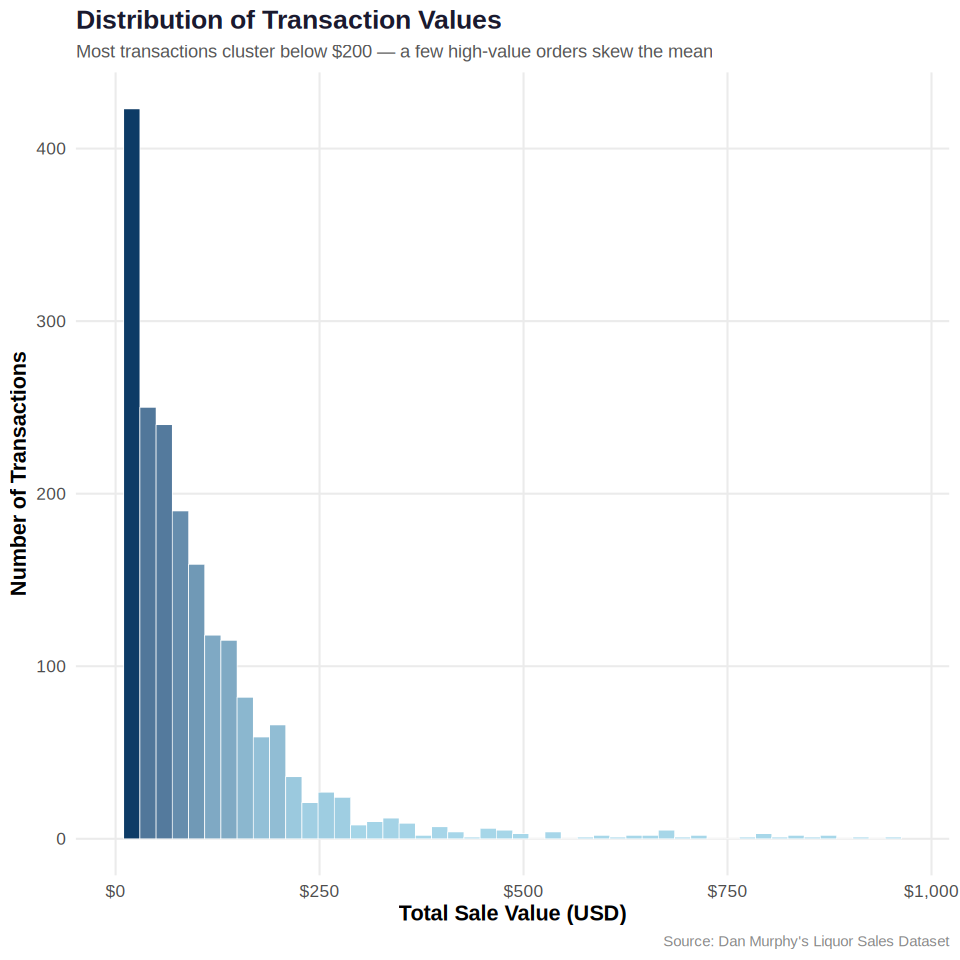

ℹ Please use `after_stat(count)` instead.
(`geom_bar()`).

In [0]:
library(scales)

p_hist <- ggplot(df, aes(x = total)) +
  geom_histogram(
    aes(fill = ..count..),
    bins    = 50,
    colour  = "white",
    linewidth = 0.2
  ) +
  scale_fill_gradient(low = "#a8d8ea", high = "#0d3b66", guide = "none") +
  scale_x_continuous(labels = dollar_format(), limits = c(0, quantile(df$total, 0.99))) +
  labs(
    title    = "Distribution of Transaction Values",
    subtitle = "Most transactions cluster below $200 \u2014 a few high-value orders skew the mean",
    x        = "Total Sale Value (USD)",
    y        = "Number of Transactions",
    caption  = "Source: Dan Murphy's Liquor Sales Dataset"
  ) +
  theme_danmurphy

print(p_hist)

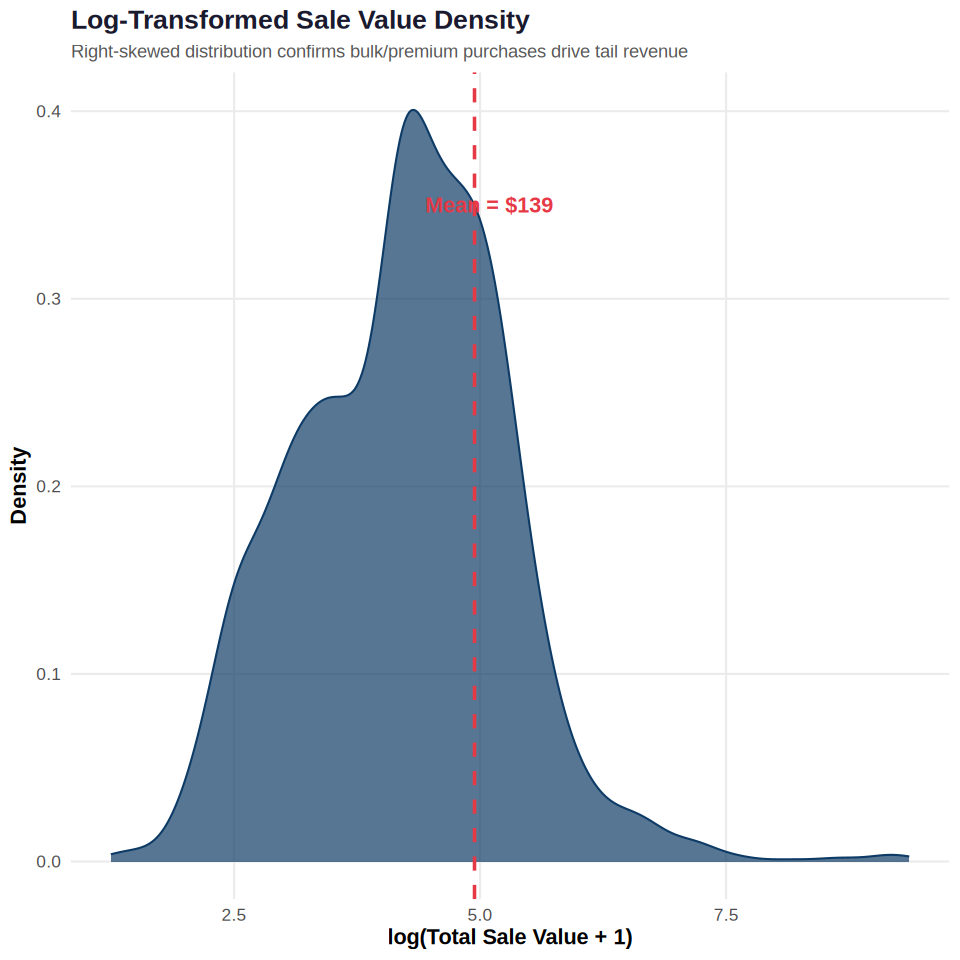

In [0]:
p_log <- ggplot(df, aes(x = log1p(total))) +
  geom_density(fill = "#0d3b66", alpha = 0.7, colour = "#0d3b66") +
  geom_vline(xintercept = log1p(mean(df$total)), linetype = "dashed",
             colour = "#e63946", linewidth = 1) +
  annotate("text", x = log1p(mean(df$total)) + 0.15, y = 0.35,
           label = paste0("Mean = $", round(mean(df$total), 0)),
           colour = "#e63946", fontface = "bold") +
  labs(
    title    = "Log-Transformed Sale Value Density",
    subtitle = "Right-skewed distribution confirms bulk/premium purchases drive tail revenue",
    x        = "log(Total Sale Value + 1)",
    y        = "Density"
  ) +
  theme_danmurphy

print(p_log)


In [0]:
library(e1071)

cat(sprintf("\n\U0001f4d0 Skewness of Total Sales : %.2f (positive = right-skewed)\n",
            skewness(df$total)))
cat(sprintf("\U0001f4d0 Kurtosis of Total Sales : %.2f (>3 = heavy tails)\n",
            kurtosis(df$total)))


📐 Skewness of Total Sales : 16.57 (positive = right-skewed)
📐 Kurtosis of Total Sales : 311.72 (>3 = heavy tails)

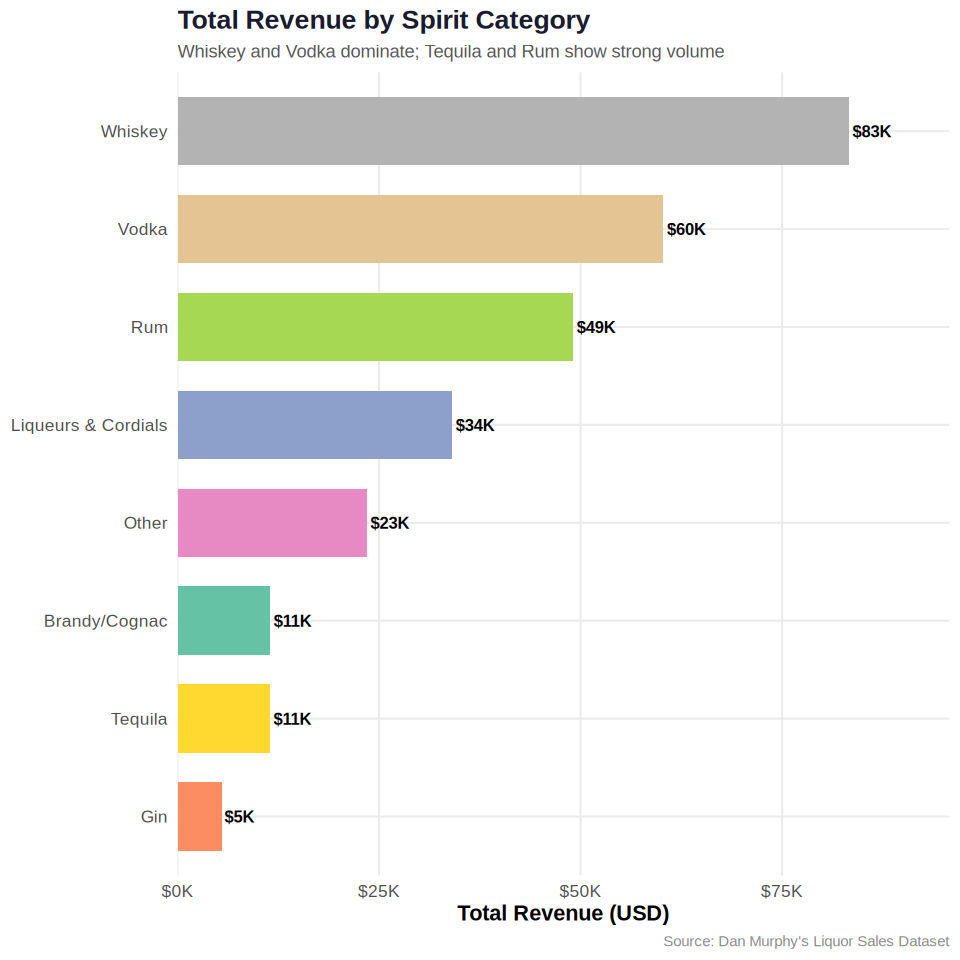

In [0]:
spirit_summary <- df %>%
  group_by(spirit_type) %>%
  summarise(
    total_revenue   = sum(total),
    transactions    = n(),
    avg_sale        = mean(total),
    avg_margin_pct  = mean(margin_pct),
    .groups = "drop"
  ) %>%
  arrange(desc(total_revenue))

knitr::kable(spirit_summary %>%
               mutate(total_revenue = dollar(total_revenue),
                      avg_sale      = dollar(round(avg_sale, 2)),
                      avg_margin_pct = paste0(round(avg_margin_pct, 1), "%")),
             caption = "💼 Revenue Summary by Spirit Type")

p_spirit_rev <- ggplot(spirit_summary,
                       aes(x = reorder(spirit_type, total_revenue),
                           y = total_revenue, fill = spirit_type)) +
  geom_col(show.legend = FALSE, width = 0.7) +
  geom_text(aes(label = dollar(round(total_revenue / 1000), suffix = "K")),
            hjust = -0.1, fontface = "bold", size = 3.5) +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K"),
                     expand = expansion(mult = c(0, 0.15))) +
  scale_fill_brewer(palette = "Set2") +
  coord_flip() +
  labs(
    title    = "Total Revenue by Spirit Category",
    subtitle = "Whiskey and Vodka dominate; Tequila and Rum show strong volume",
    x        = NULL,
    y        = "Total Revenue (USD)",
    caption  = "Source: Dan Murphy's Liquor Sales Dataset"
  ) +
  theme_danmurphy

print(p_spirit_rev)

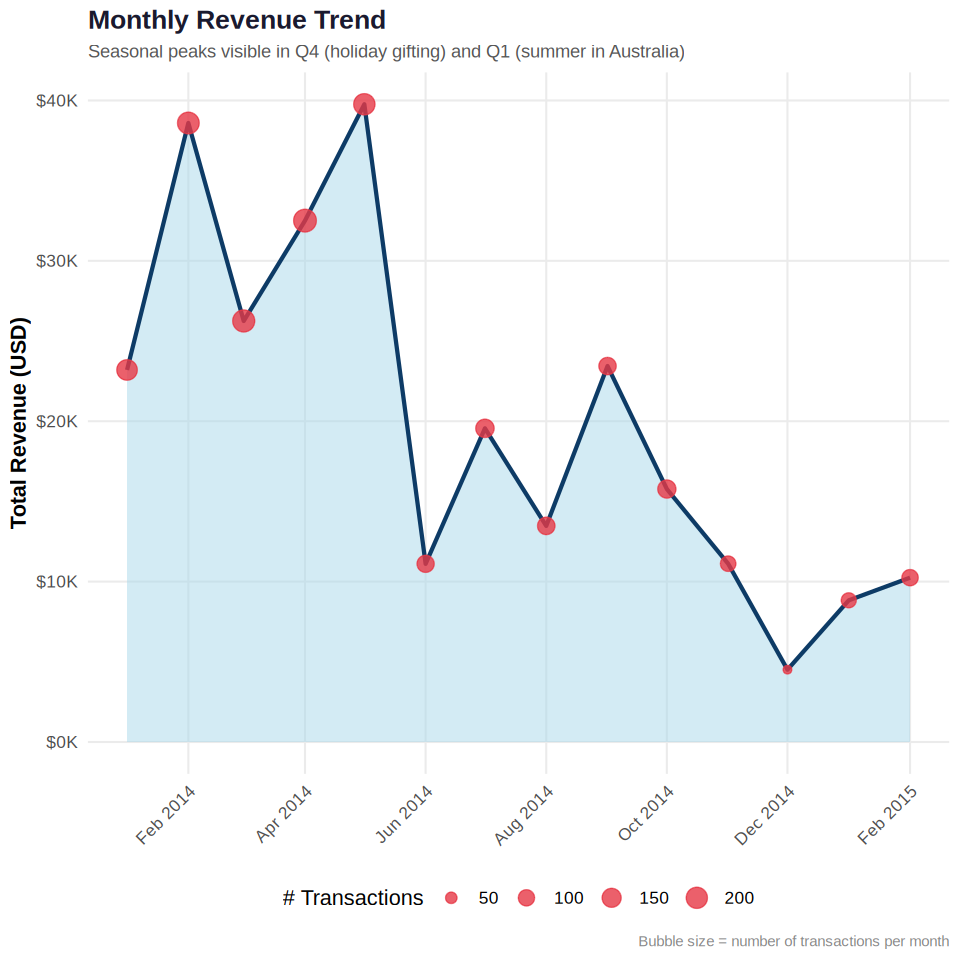

In [0]:
monthly_trend <- df %>%
  mutate(year_month = floor_date(date, "month")) %>%
  group_by(year_month) %>%
  summarise(
    revenue      = sum(total),
    transactions = n(),
    avg_sale     = mean(total),
    .groups = "drop"
  )

p_trend <- ggplot(monthly_trend, aes(x = year_month, y = revenue)) +
  geom_area(fill = "#a8d8ea", alpha = 0.5) +
  geom_line(colour = "#0d3b66", linewidth = 1.2) +
  geom_point(aes(size = transactions), colour = "#e63946", alpha = 0.8) +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K")) +
  scale_x_datetime(date_labels = "%b %Y", date_breaks = "2 months") +
  scale_size_continuous(range = c(2, 6), guide = "legend", name = "# Transactions") +
  labs(
    title    = "Monthly Revenue Trend",
    subtitle = "Seasonal peaks visible in Q4 (holiday gifting) and Q1 (summer in Australia)",
    x        = NULL,
    y        = "Total Revenue (USD)",
    caption  = "Bubble size = number of transactions per month"
  ) +
  theme_danmurphy +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p_trend)


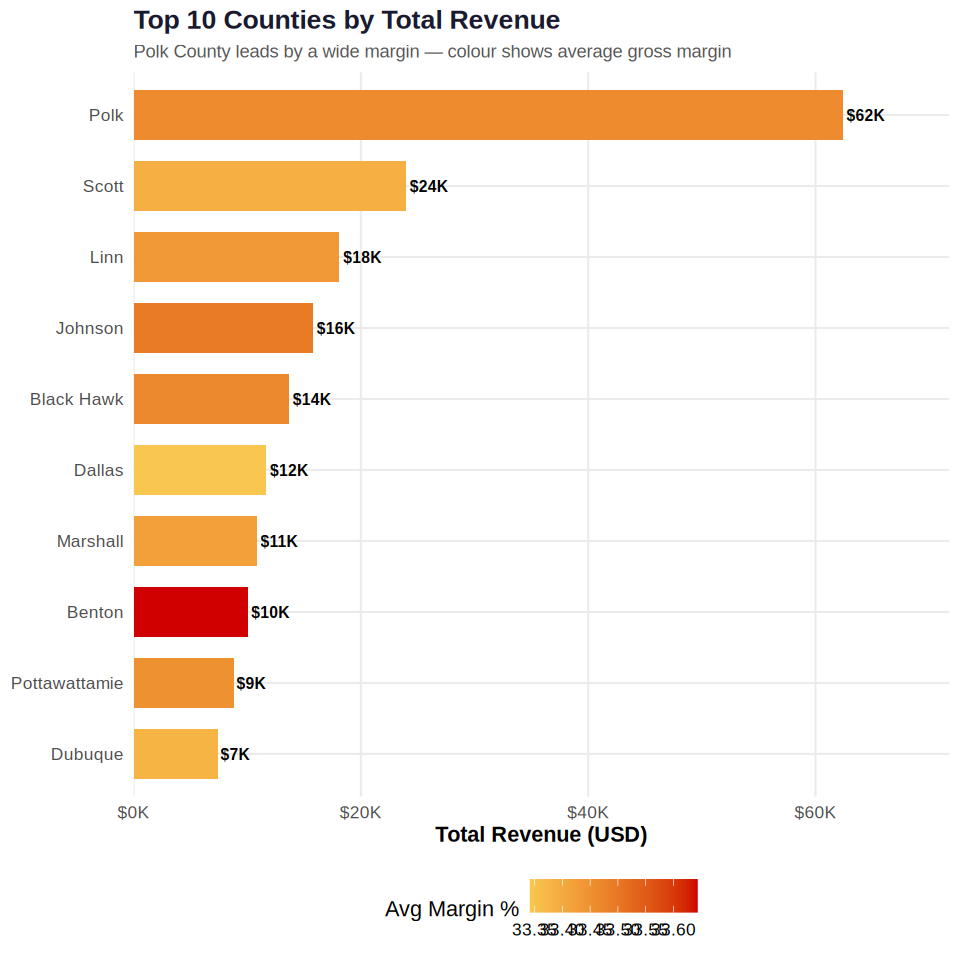

In [0]:
county_rev <- df %>%
  group_by(county) %>%
  summarise(
    revenue      = sum(total),
    transactions = n(),
    avg_margin   = mean(margin_pct),
    .groups = "drop"
  ) %>%
  arrange(desc(revenue)) %>%
  slice_head(n = 10)

p_county <- ggplot(county_rev,
                   aes(x = reorder(county, revenue), y = revenue, fill = avg_margin)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = dollar(round(revenue / 1000), suffix = "K")),
            hjust = -0.1, fontface = "bold", size = 3.3) +
  scale_fill_gradient(low = "#f9c74f", high = "#d00000",
                      name = "Avg Margin %") +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K"),
                     expand = expansion(mult = c(0, 0.15))) +
  coord_flip() +
  labs(
    title    = "Top 10 Counties by Total Revenue",
    subtitle = "Polk County leads by a wide margin — colour shows average gross margin",
    x        = NULL, y = "Total Revenue (USD)"
  ) +
  theme_danmurphy

print(p_county)



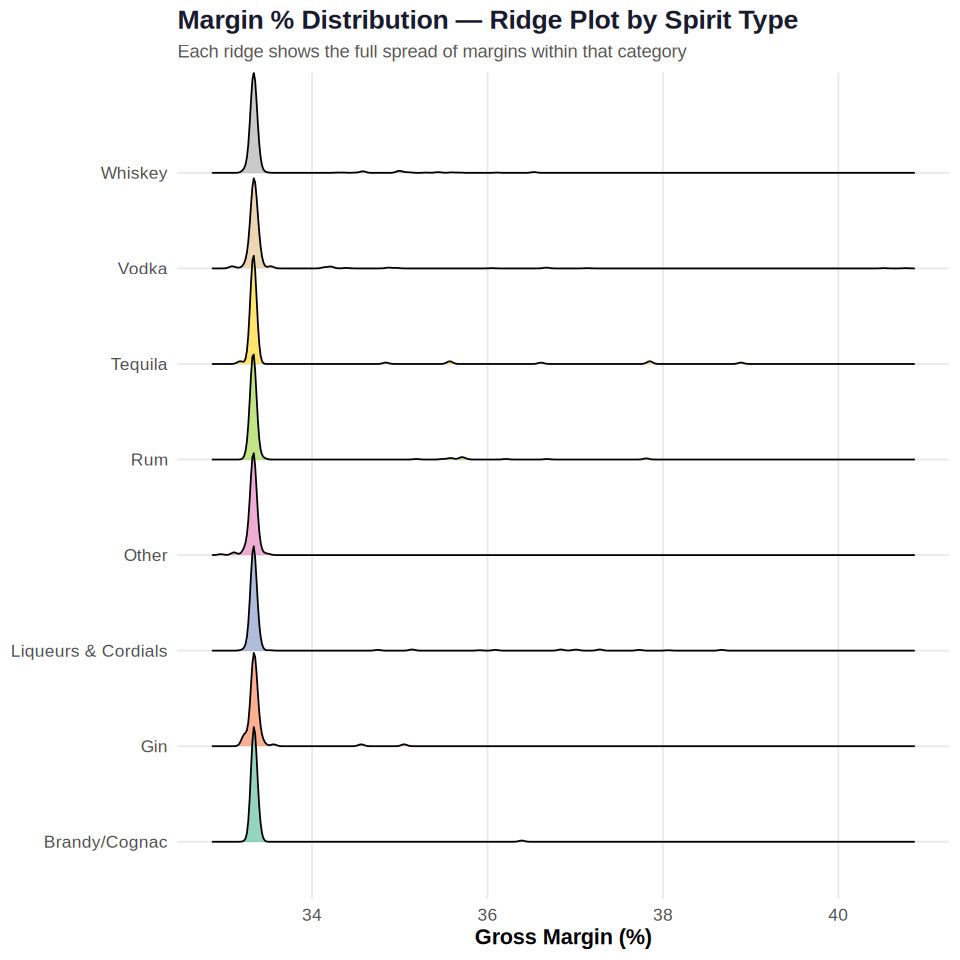

Picking joint bandwidth of 0.0314

In [0]:
library(ggridges)

# Box-plot: margin % by spirit type
p_margin_box <- ggplot(df, aes(x = reorder(spirit_type, margin_pct, median),
                               y = margin_pct, fill = spirit_type)) +
  geom_boxplot(outlier.size = 0.7, outlier.alpha = 0.4, show.legend = FALSE) +
  geom_hline(yintercept = mean(df$margin_pct), linetype = "dashed",
             colour = "#e63946", linewidth = 1) +
  annotate("text", x = 1, y = mean(df$margin_pct) + 1.5,
           label = paste0("Overall Avg: ", round(mean(df$margin_pct), 1), "%"),
           colour = "#e63946", size = 3.5) +
  scale_fill_brewer(palette = "Pastel2") +
  coord_flip() +
  labs(
    title    = "Gross Margin % Distribution by Spirit Type",
    subtitle = "Liqueurs & Cordials achieve the highest margins; Vodka shows tightest spread",
    x        = NULL, y = "Gross Margin (%)"
  ) +
  theme_danmurphy

print(p_margin_box)

# Ridge plot: distribution shape of margins
p_ridge <- ggplot(df, aes(x = margin_pct, y = spirit_type, fill = spirit_type)) +
  geom_density_ridges(alpha = 0.7, scale = 1.2, show.legend = FALSE) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title    = "Margin % Distribution \u2014 Ridge Plot by Spirit Type",
    subtitle = "Each ridge shows the full spread of margins within that category",
    x        = "Gross Margin (%)", y = NULL
  ) +
  theme_danmurphy

print(p_ridge)

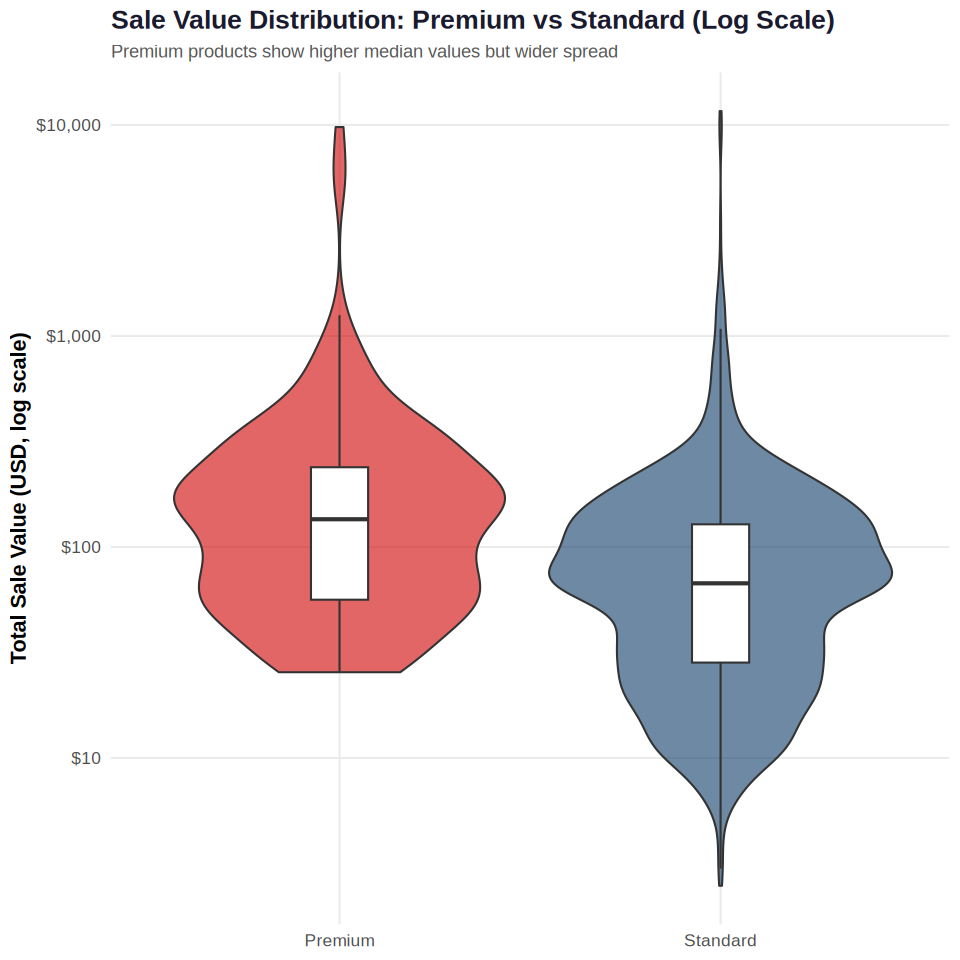

In [0]:
premium_summary <- df %>%
  group_by(is_premium) %>%
  summarise(
    n             = n(),
    total_rev     = sum(total),
    avg_sale      = mean(total),
    avg_margin    = mean(margin_pct),
    avg_qty       = mean(bottle_qty),
    .groups = "drop"
  )

knitr::kable(premium_summary %>%
               mutate(total_rev  = dollar(round(total_rev)),
                      avg_sale   = dollar(round(avg_sale, 2)),
                      avg_margin = paste0(round(avg_margin, 1), "%"),
                      avg_qty    = round(avg_qty, 1)),
             caption = "🏷️  Premium vs Standard Product Comparison")

p_prem <- ggplot(df, aes(x = is_premium, y = total, fill = is_premium)) +
  geom_violin(alpha = 0.6, trim = TRUE, show.legend = FALSE) +
  geom_boxplot(width = 0.15, fill = "white", outlier.shape = NA) +
  scale_y_log10(labels = dollar_format()) +
  scale_fill_manual(values = c("Premium" = "#d00000", "Standard" = "#0d3b66")) +
  labs(
    title    = "Sale Value Distribution: Premium vs Standard (Log Scale)",
    subtitle = "Premium products show higher median values but wider spread",
    x        = NULL, y = "Total Sale Value (USD, log scale)"
  ) +
  theme_danmurphy

print(p_prem)



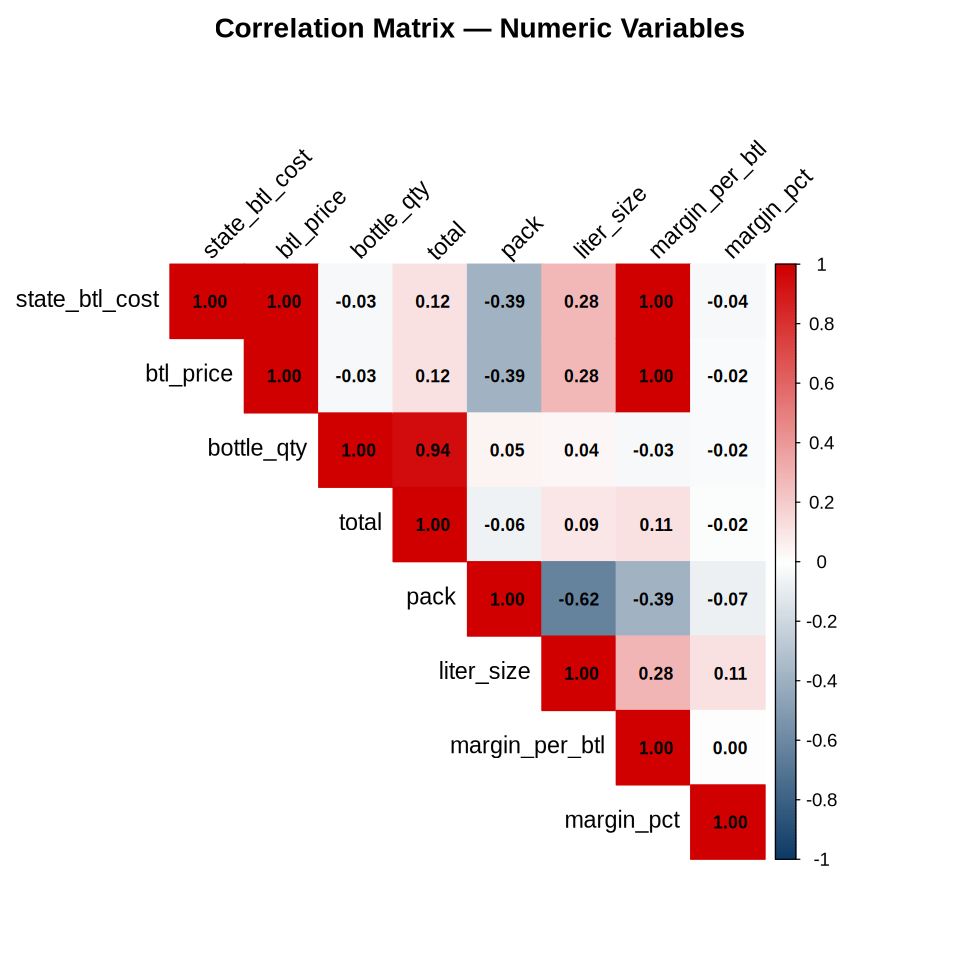

corrplot 0.95 loaded

📋 Key Correlations:
  btl_price ↔ total        : 0.12
  bottle_qty ↔ total       : 0.94
  liter_size ↔ btl_price   : 0.28
  margin_pct ↔ btl_price   : -0.02

In [0]:
library(corrplot)

numeric_cols <- df %>%
  select(state_btl_cost, btl_price, bottle_qty, total, pack,
         liter_size, margin_per_btl, margin_pct) %>%
  na.omit()

cor_matrix <- cor(numeric_cols)

corrplot(
  cor_matrix,
  method      = "color",
  type        = "upper",
  addCoef.col = "black",
  tl.col      = "black",
  tl.srt      = 45,
  number.cex  = 0.75,
  col         = colorRampPalette(c("#0d3b66", "white", "#d00000"))(200),
  title       = "Correlation Matrix \u2014 Numeric Variables",
  mar         = c(0, 0, 2, 0)
)

cat("\n\U0001f4cb Key Correlations:\n")
cat(sprintf("  btl_price \u2194 total        : %.2f\n", cor(df$btl_price, df$total)))
cat(sprintf("  bottle_qty \u2194 total       : %.2f\n", cor(df$bottle_qty, df$total)))
cat(sprintf("  liter_size \u2194 btl_price   : %.2f\n", cor(df$liter_size, df$btl_price)))
cat(sprintf("  margin_pct \u2194 btl_price   : %.2f\n", cor(df$margin_pct, df$btl_price)))

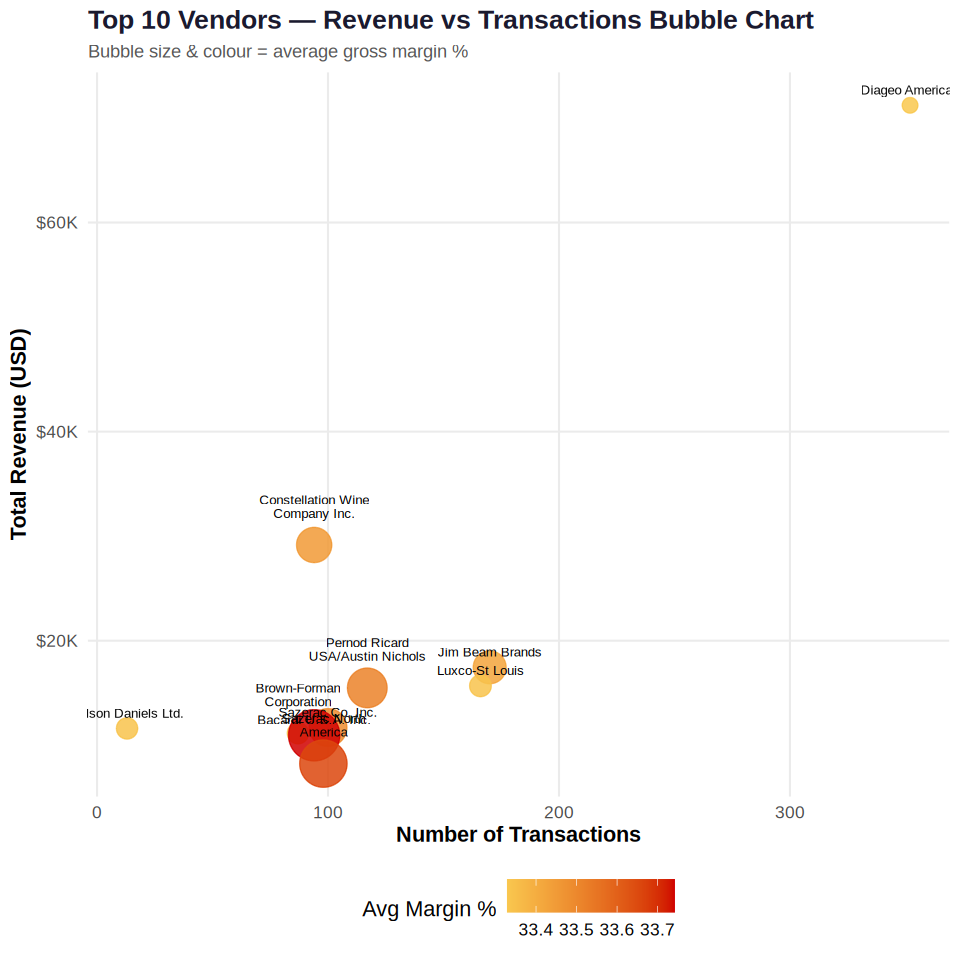

In [0]:
library(stringr)

vendor_perf <- df %>%
  group_by(vendor) %>%
  summarise(
    revenue      = sum(total),
    transactions = n(),
    avg_margin   = mean(margin_pct),
    .groups = "drop"
  ) %>%
  arrange(desc(revenue)) %>%
  slice_head(n = 10)

p_vendor <- ggplot(vendor_perf,
                   aes(x = transactions, y = revenue,
                       size = avg_margin, label = str_wrap(vendor, 20))) +
  geom_point(aes(colour = avg_margin), alpha = 0.85) +
  geom_text(size = 2.8, vjust = -1.2, lineheight = 0.85) +
  scale_colour_gradient(low = "#f9c74f", high = "#d00000", name = "Avg Margin %") +
  scale_size_continuous(range = c(4, 14), guide = "none") +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K")) +
  labs(
    title    = "Top 10 Vendors \u2014 Revenue vs Transactions Bubble Chart",
    subtitle = "Bubble size & colour = average gross margin %",
    x        = "Number of Transactions",
    y        = "Total Revenue (USD)"
  ) +
  theme_danmurphy

print(p_vendor)

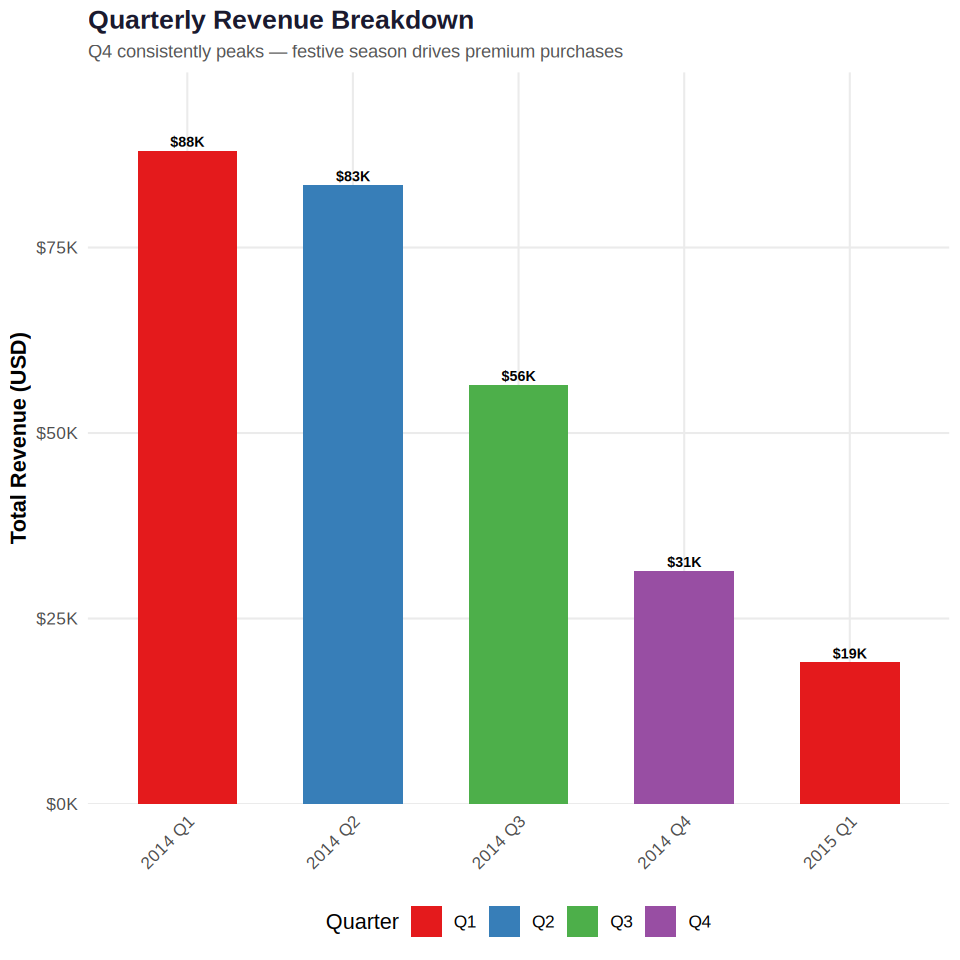

In [0]:
quarterly <- df %>%
  group_by(year, quarter) %>%
  summarise(revenue = sum(total), n = n(), .groups = "drop") %>%
  mutate(yr_q = paste0(year, " ", quarter))

p_quarterly <- ggplot(quarterly, aes(x = yr_q, y = revenue, fill = quarter)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = dollar(round(revenue / 1000), suffix = "K")),
            vjust = -0.4, size = 3, fontface = "bold") +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K"),
                     expand = expansion(mult = c(0, 0.12))) +
  scale_fill_brewer(palette = "Set1", name = "Quarter") +
  labs(
    title    = "Quarterly Revenue Breakdown",
    subtitle = "Q4 consistently peaks — festive season drives premium purchases",
    x        = NULL, y = "Total Revenue (USD)"
  ) +
  theme_danmurphy +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p_quarterly)

In [0]:
cat("\n══════════════════════════════════════════════════════════\n")
cat("  HYPOTHESIS TEST 1 — Independent Samples t-Test          \n")
cat("══════════════════════════════════════════════════════════\n")
cat("H₀ : μ_Premium = μ_Standard (mean total sale value)\n")
cat("H₁ : μ_Premium > μ_Standard\n")
cat("α  : 0.05\n\n")

premium_vals  <- df %>% filter(is_premium == "Premium")  %>% pull(total)
standard_vals <- df %>% filter(is_premium == "Standard") %>% pull(total)

# Normality check (Shapiro on sample due to size)
set.seed(42)
sw_prem <- shapiro.test(sample(premium_vals,  min(5000, length(premium_vals))))
sw_std  <- shapiro.test(sample(standard_vals, min(5000, length(standard_vals))))
cat(sprintf("Shapiro-Wilk (Premium)  : W=%.4f, p=%.4f\n", sw_prem$statistic, sw_prem$p.value))
cat(sprintf("Shapiro-Wilk (Standard) : W=%.4f, p=%.4f\n", sw_std$statistic,  sw_std$p.value))
cat("→ Data not normally distributed; Welch's t-test is robust to this\n\n")

# Welch's t-test (does not assume equal variance)
t_result <- t.test(premium_vals, standard_vals, alternative = "greater", var.equal = FALSE)
print(t_result)

cat("\n📌 INTERPRETATION:\n")
if (t_result$p.value < 0.05) {
  cat(sprintf(
    "  p-value = %.4f < 0.05 → REJECT H₀\n  ✅ Premium products generate significantly higher sales values\n",
    t_result$p.value
  ))
} else {
  cat(sprintf(
    "  p-value = %.4f ≥ 0.05 → FAIL TO REJECT H₀\n  ❌ No significant difference detected\n",
    t_result$p.value
  ))
}

# Effect size (Cohen's d)
pooled_sd <- sqrt((var(premium_vals) * (length(premium_vals) - 1) +
                   var(standard_vals) * (length(standard_vals) - 1)) /
                  (length(premium_vals) + length(standard_vals) - 2))
cohens_d  <- (mean(premium_vals) - mean(standard_vals)) / pooled_sd
cat(sprintf("  Cohen's d = %.3f (%s effect)\n", cohens_d,
            ifelse(abs(cohens_d) >= 0.8, "Large",
                   ifelse(abs(cohens_d) >= 0.5, "Medium", "Small"))))




══════════════════════════════════════════════════════════
  HYPOTHESIS TEST 1 — Independent Samples t-Test          
══════════════════════════════════════════════════════════
H₀ : μ_Premium = μ_Standard (mean total sale value)
H₁ : μ_Premium > μ_Standard
α  : 0.05

Shapiro-Wilk (Premium)  : W=0.2182, p=0.0000
Shapiro-Wilk (Standard) : W=0.1389, p=0.0000
→ Data not normally distributed; Welch's t-test is robust to this


	Welch Two Sample t-test

data:  premium_vals and standard_vals
t = 2.5569, df = 213.64, p-value = 0.005627
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 56.97218      Inf
sample estimates:
mean of x mean of y 
 283.8274  122.8480 


📌 INTERPRETATION:
  p-value = 0.0056 < 0.05 → REJECT H₀
  ✅ Premium products generate significantly higher sales values
  Cohen's d = 0.318 (Small effect)

In [0]:
library(car)

cat("\n\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")
cat("  HYPOTHESIS TEST 2 \u2014 One-Way ANOVA (Spirit Type)         \n")
cat("\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")
cat("H\u2080 : \u03bc_Vodka = \u03bc_Whiskey = \u03bc_Rum = \u03bc_Tequila = ... (all equal)\n")
cat("H\u2081 : At least one group mean differs\n")
cat("\u03b1  : 0.05\n\n")

# ANOVA assumption: Levene's test for homogeneity of variance
levene_result <- leveneTest(total ~ spirit_type, data = df)
print(levene_result)

cat("\n\u2192 Running Welch ANOVA (robust to unequal variances):\n\n")

# Welch's ANOVA (oneway.test)
welch_anova <- oneway.test(total ~ spirit_type, data = df, var.equal = FALSE)
print(welch_anova)

cat("\n\U0001f4cc INTERPRETATION:\n")
if (welch_anova$p.value < 0.05) {
  cat(sprintf("  p-value = %.4f < 0.05 \u2192 REJECT H\u2080\n", welch_anova$p.value))
  cat("  \u2705 Significant difference in mean sales exists across spirit types\n")
} else {
  cat(sprintf("  p-value = %.4f \u2265 0.05 \u2192 FAIL TO REJECT H\u2080\n", welch_anova$p.value))
}

# Standard ANOVA table for reference
anova_model <- aov(total ~ spirit_type, data = df)
cat("\n\U0001f4cb Classic ANOVA Table:\n")
print(summary(anova_model))

# Eta-squared (effect size)
ss_between <- summary(anova_model)[[1]][["Sum Sq"]][1]
ss_total   <- sum(summary(anova_model)[[1]][["Sum Sq"]])
eta_sq     <- ss_between / ss_total
cat(sprintf("\n  \u03b7\u00b2 (Eta-squared) = %.4f \u2192 %.1f%% of variance explained by spirit type\n",
            eta_sq, eta_sq * 100))

Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode


══════════════════════════════════════════════════════════
  HYPOTHESIS TEST 2 — One-Way ANOVA (Spirit Type)         
══════════════════════════════════════════════════════════
H₀ : μ_Vodka = μ_Whiskey = μ_Rum = μ_Tequila = ... (all equal)
H₁ : At least one group mean differs
α  : 0.05

Levene's Test for Homogeneity of Variance (center = median)
        Df F value Pr(>F)
group    7  1.2219  0.287
      1992               

→ Running Welch ANOVA (robust to unequal variances):


	One-way analysis of means (not assuming equal variances)

data:  total and spirit_type
F = 2.7752, num df = 7.00, denom df = 546.42, p-value = 0.007654


📌 INTERPRETATION:
  p-value = 0.0077 < 0.05 → REJECT H₀
  ✅ Significant difference in mean sales exists across spirit types

📋 Classic ANOVA Table:
              Df    Sum Sq Mean Sq F value Pr(>F)
spirit_type    7   2552101  364586   

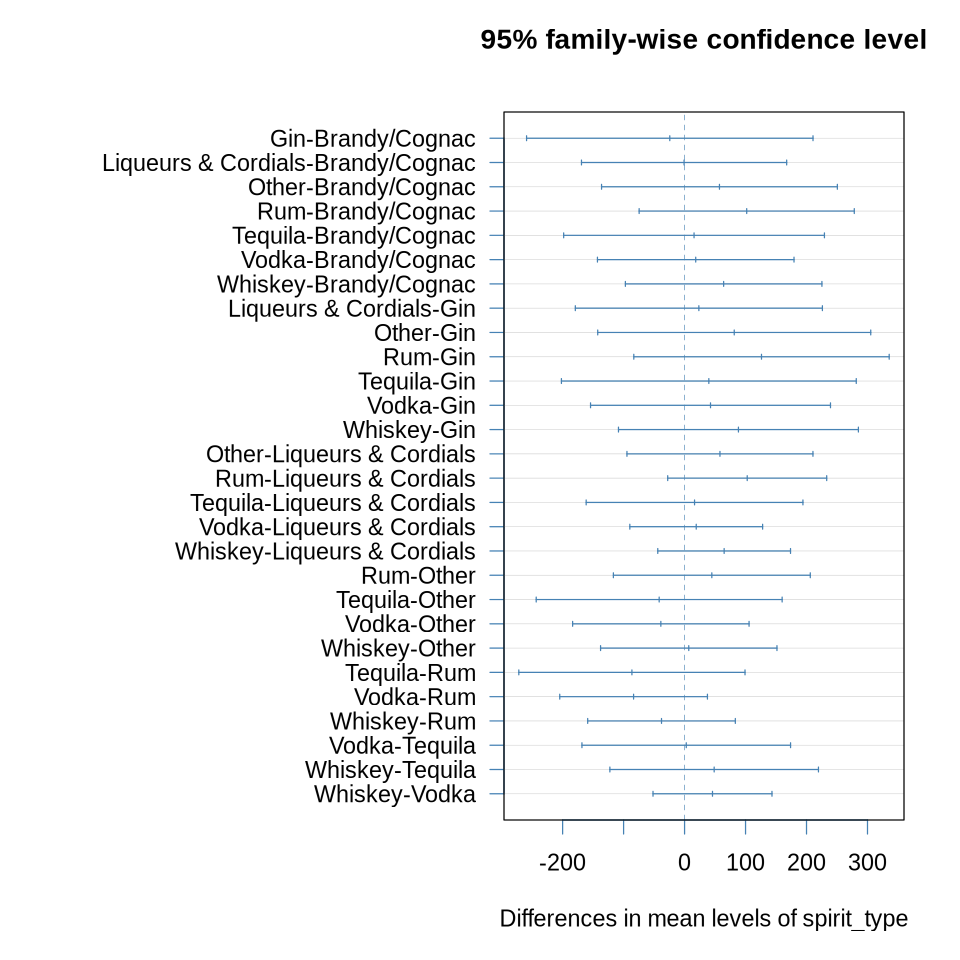


══════════════════════════════════════════════════════════
  POST-HOC — Tukey HSD (Pairwise Comparisons)             
══════════════════════════════════════════════════════════
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = total ~ spirit_type, data = df)

$spirit_type
                                         diff        lwr       upr     p adj
Gin-Brandy/Cognac                 -24.2483571 -259.13499 210.63827 0.9999858
Liqueurs & Cordials-Brandy/Cognac  -0.8196386 -169.08820 167.44892 1.0000000
Other-Brandy/Cognac                57.2045748 -136.15373 250.56288 0.9863248
Rum-Brandy/Cognac                 101.9078452  -74.50790 278.32359 0.6523345
Tequila-Brandy/Cognac              15.5441863 -198.28102 229.36939 0.9999987
Vodka-Brandy/Cognac                18.2943795 -142.89705 179.48581 0.9999728
Whiskey-Brandy/Cognac              64.0821086  -97.07977 225.24399 0.9302213
Liqueurs & Cordials-Gin            23.4287186 -179.17001 226.0274

In [0]:
cat("\n\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")
cat("  POST-HOC \u2014 Tukey HSD (Pairwise Comparisons)             \n")
cat("\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")

tukey_result <- TukeyHSD(anova_model)
print(tukey_result)

# Visualise Tukey
par(mar = c(5, 18, 4, 2))
plot(tukey_result, las = 1, col = "steelblue")
par(mar = c(5, 4, 4, 2))  # reset margins

cat("\n\U0001f4cc Pairs whose confidence interval does NOT cross zero are significantly different.\n")

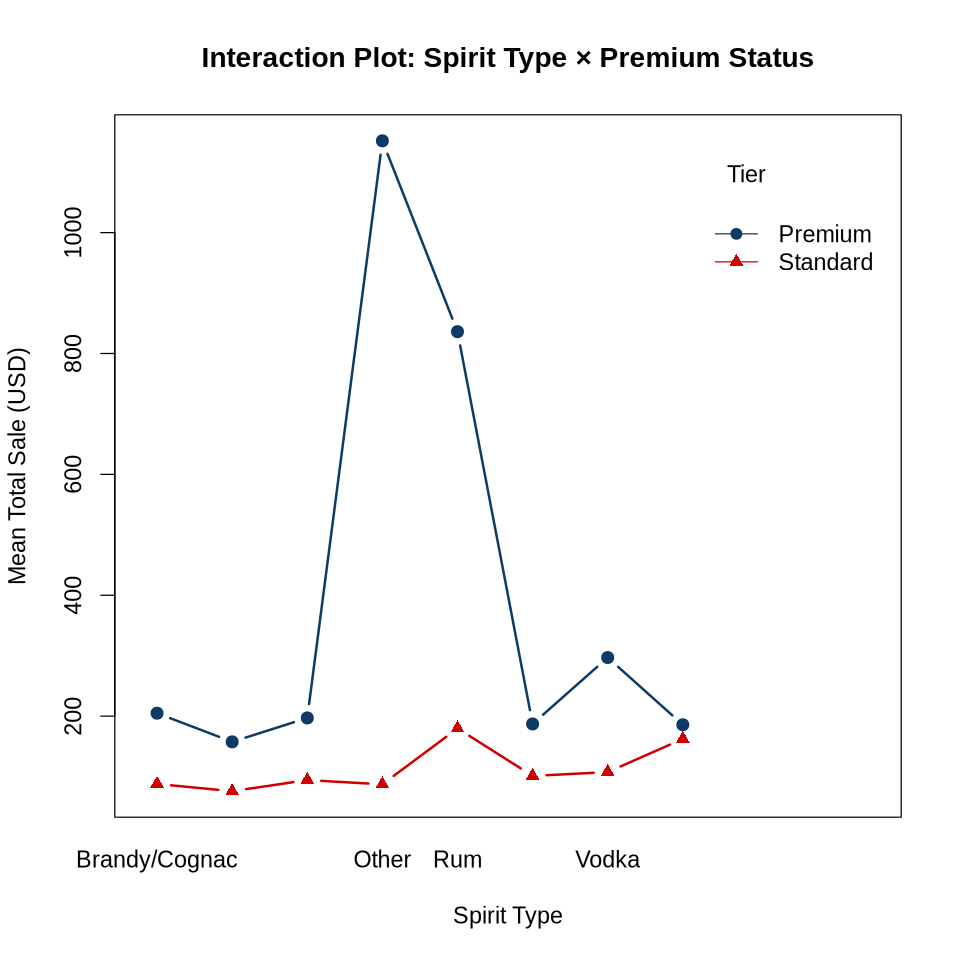


══════════════════════════════════════════════════════════
  HYPOTHESIS TEST 3 — Two-Way ANOVA                       
  Factors: Spirit Type × Premium Status                   
══════════════════════════════════════════════════════════

📋 Two-Way ANOVA Table:
                         Df    Sum Sq Mean Sq F value   Pr(>F)    
spirit_type               7   2552101  364586   1.452     0.18    
is_premium                1   4679734 4679734  18.635 1.66e-05 ***
spirit_type:is_premium    7  11356674 1622382   6.461 1.51e-07 ***
Residuals              1984 498226733  251122                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

📌 If the lines cross, a significant INTERACTION exists —
   meaning the premium effect varies by spirit type.

In [0]:
cat("\n══════════════════════════════════════════════════════════\n")
cat("  HYPOTHESIS TEST 3 — Two-Way ANOVA                       \n")
cat("  Factors: Spirit Type × Premium Status                   \n")
cat("══════════════════════════════════════════════════════════\n")

two_way_anova <- aov(total ~ spirit_type * is_premium, data = df)
cat("\n📋 Two-Way ANOVA Table:\n")
print(summary(two_way_anova))

# Interaction plot
interaction.plot(
  x.factor     = df$spirit_type,
  trace.factor  = df$is_premium,
  response      = df$total,
  fun           = mean,
  type          = "b",
  col           = c("#0d3b66", "#d00000"),
  lty           = 1,
  lwd           = 2,
  pch           = c(19, 17),
  legend        = TRUE,
  xlab          = "Spirit Type",
  ylab          = "Mean Total Sale (USD)",
  main          = "Interaction Plot: Spirit Type × Premium Status",
  trace.label   = "Tier"
)

cat("\n📌 If the lines cross, a significant INTERACTION exists —\n")
cat("   meaning the premium effect varies by spirit type.\n")


In [0]:
cat("\n══════════════════════════════════════════════════════════\n")
cat("  HYPOTHESIS TEST 4 — Chi-Square Test of Independence     \n")
cat("══════════════════════════════════════════════════════════\n")
cat("H₀ : Spirit type is independent of bottle size category\n")
cat("H₁ : There is a significant association between them\n\n")

contingency_table <- table(df$spirit_type, df$size_category)
print(contingency_table)

chi_result <- chisq.test(contingency_table)
print(chi_result)

# Cramér's V (effect size)
n      <- sum(contingency_table)
k      <- min(nrow(contingency_table), ncol(contingency_table))
cramers_v <- sqrt(chi_result$statistic / (n * (k - 1)))
cat(sprintf("\n  Cramér's V = %.4f (effect size: %s)\n", cramers_v,
            ifelse(cramers_v >= 0.3, "Large",
                   ifelse(cramers_v >= 0.1, "Medium", "Small"))))

cat("\n📌 INTERPRETATION:\n")
if (chi_result$p.value < 0.05) {
  cat(sprintf("  p-value = %.4e < 0.05 → REJECT H₀\n", chi_result$p.value))
  cat("  ✅ Spirit type and bottle size category are NOT independent\n")
}



══════════════════════════════════════════════════════════
  HYPOTHESIS TEST 4 — Chi-Square Test of Independence     
══════════════════════════════════════════════════════════
H₀ : Spirit type is independent of bottle size category
H₁ : There is a significant association between them

                     
                      Mini (≤375 ml) Standard (376–750 ml) Litre (751–1 000 ml)
  Brandy/Cognac                   44                    51                    8
  Gin                             12                    34                   11
  Liqueurs & Cordials             23                   190                   64
  Other                           17                    80                   17
  Rum                             24                   130                   35
  Tequila                         15                    63                   16
  Vodka                           61                   277                   65
  Whiskey                         77              

In [0]:
library(dunn.test)

cat("\n\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")
cat("  HYPOTHESIS TEST 5 \u2014 Kruskal-Wallis + Dunn Post-Hoc      \n")
cat("  DV: Margin %   |   Groups: Bottle Size Category         \n")
cat("\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")
cat("H\u2080 : Median margin % is equal across all size categories\n")
cat("H\u2081 : At least one size category has a different median margin %\n\n")

kw_result <- kruskal.test(margin_pct ~ size_category, data = df)
print(kw_result)

cat("\n\U0001f4cc Dunn Post-Hoc Test (Bonferroni adjustment):\n")
dunn.test(df$margin_pct, df$size_category, method = "bonferroni")


══════════════════════════════════════════════════════════
  HYPOTHESIS TEST 5 — Kruskal-Wallis + Dunn Post-Hoc      
  DV: Margin %   |   Groups: Bottle Size Category         
══════════════════════════════════════════════════════════
H₀ : Median margin % is equal across all size categories
H₁ : At least one size category has a different median margin %


	Kruskal-Wallis rank sum test

data:  margin_pct by size_category
Kruskal-Wallis chi-squared = 13.997, df = 3, p-value = 0.00291


📌 Dunn Post-Hoc Test (Bonferroni adjustment):
  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 13.9967, df = 3, p-value = 0


                   Dunn's Pairwise Comparison of x by group                   
                                 (Bonferroni)                                 
Col Mean-│
Row Mean │   Large (>   Litre (7   Mini (≤3
─────────┼─────────────────────────────────
Litre (7 │   2.919832
         │     0.0105*
         │
Mini (≤3 │   0.432186  -2.316315
       

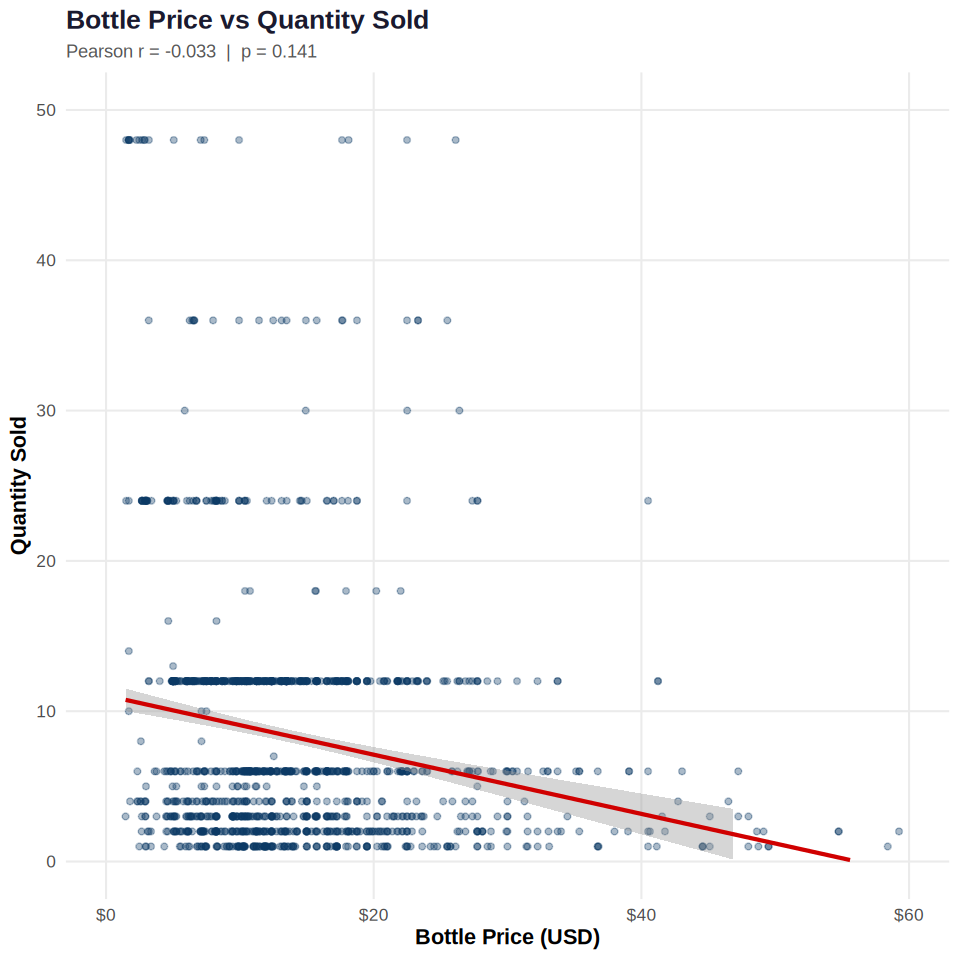


══════════════════════════════════════════════════════════
  HYPOTHESIS TEST 6 — Pearson Correlation Test            
  btl_price ↔ bottle_qty                                  
══════════════════════════════════════════════════════════

	Pearson's product-moment correlation

data:  df$btl_price and df$bottle_qty
t = -1.4743, df = 1998, p-value = 0.1406
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.07668504  0.01088175
sample estimates:
        cor 
-0.03296491 


📌 INTERPRETATION:
  r = -0.0330  |  p-value = 0.1406
`geom_smooth()` using formula = 'y ~ x'
(`stat_smooth()`).
(`geom_point()`).
(`geom_smooth()`).

In [0]:
cat("\n══════════════════════════════════════════════════════════\n")
cat("  HYPOTHESIS TEST 6 — Pearson Correlation Test            \n")
cat("  btl_price ↔ bottle_qty                                  \n")
cat("══════════════════════════════════════════════════════════\n")

cor_test <- cor.test(df$btl_price, df$bottle_qty, method = "pearson")
print(cor_test)

cat("\n📌 INTERPRETATION:\n")
cat(sprintf("  r = %.4f  |  p-value = %.4f\n", cor_test$estimate, cor_test$p.value))
if (cor_test$p.value < 0.05) {
  direction <- ifelse(cor_test$estimate > 0, "positive", "negative")
  strength  <- ifelse(abs(cor_test$estimate) >= 0.5, "strong", "weak")
  cat(sprintf("  ✅ Significant %s %s correlation\n", strength, direction))
}

# Scatter with smooth
p_scatter <- ggplot(df %>% sample_n(min(1500, nrow(df))),
                    aes(x = btl_price, y = bottle_qty)) +
  geom_point(alpha = 0.35, colour = "#0d3b66", size = 1.5) +
  geom_smooth(method = "lm", colour = "#d00000", linewidth = 1.2, se = TRUE) +
  scale_x_continuous(labels = dollar_format(), limits = c(0, 60)) +
  scale_y_continuous(limits = c(0, 50)) +
  labs(
    title    = "Bottle Price vs Quantity Sold",
    subtitle = paste0("Pearson r = ", round(cor_test$estimate, 3),
                      "  |  p = ", format.pval(cor_test$p.value, digits = 3)),
    x        = "Bottle Price (USD)", y = "Quantity Sold"
  ) +
  theme_danmurphy

print(p_scatter)


In [0]:
library(broom)

cat("\n\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")
cat("  REGRESSION \u2014 Multiple Linear Regression                  \n")
cat("  DV: log(total)   |   IVs: btl_price, bottle_qty,        \n")
cat("      liter_size, spirit_type, is_premium                 \n")
cat("\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")

# Log-transform DV to handle right skew
df_reg <- df %>%
  mutate(log_total = log1p(total)) %>%
  filter(is.finite(log_total))

mlr_model <- lm(
  log_total ~ btl_price + bottle_qty + liter_size + spirit_type + is_premium,
  data = df_reg
)

cat("\n\U0001f4cb Regression Summary:\n")
print(summary(mlr_model))

# Tidy output
cat("\n\U0001f4cb Tidy Coefficient Table:\n")
tidy_coef <- tidy(mlr_model) %>%
  mutate(
    significance = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01  ~ "**",
      p.value < 0.05  ~ "*",
      p.value < 0.1   ~ ".",
      TRUE            ~ ""
    )
  )
knitr::kable(tidy_coef %>%
               mutate(across(where(is.numeric), ~round(., 4))),
             caption = "MLR Coefficient Table")

# Model performance
glance_result <- glance(mlr_model)
cat(sprintf("\n  R\u00b2         = %.4f\n",  glance_result$r.squared))
cat(sprintf("  Adj. R\u00b2    = %.4f\n",  glance_result$adj.r.squared))
cat(sprintf("  F-stat     = %.2f  (p = %.2e)\n",
            glance_result$statistic, glance_result$p.value))
cat(sprintf("  AIC        = %.2f\n",  glance_result$AIC))


══════════════════════════════════════════════════════════
  REGRESSION — Multiple Linear Regression                  
  DV: log(total)   |   IVs: btl_price, bottle_qty,        
      liter_size, spirit_type, is_premium                 
══════════════════════════════════════════════════════════

📋 Regression Summary:

Call:
lm(formula = log_total ~ btl_price + bottle_qty + liter_size + 
    spirit_type + is_premium, data = df_reg)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.6143 -0.5691  0.0130  0.6908  2.0505 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     3.016e+00  1.391e-01  21.679  < 2e-16 ***
btl_price                       4.260e-02  3.424e-03  12.441  < 2e-16 ***
bottle_qty                      1.758e-02  6.686e-04  26.297  < 2e-16 ***
liter_size                      4.033e-04  4.484e-05   8.994  < 2e-16 ***
spirit_typeGin                 -3.590e-01  1.291e-01  -2.781  0.00547 ** 
spirit_type

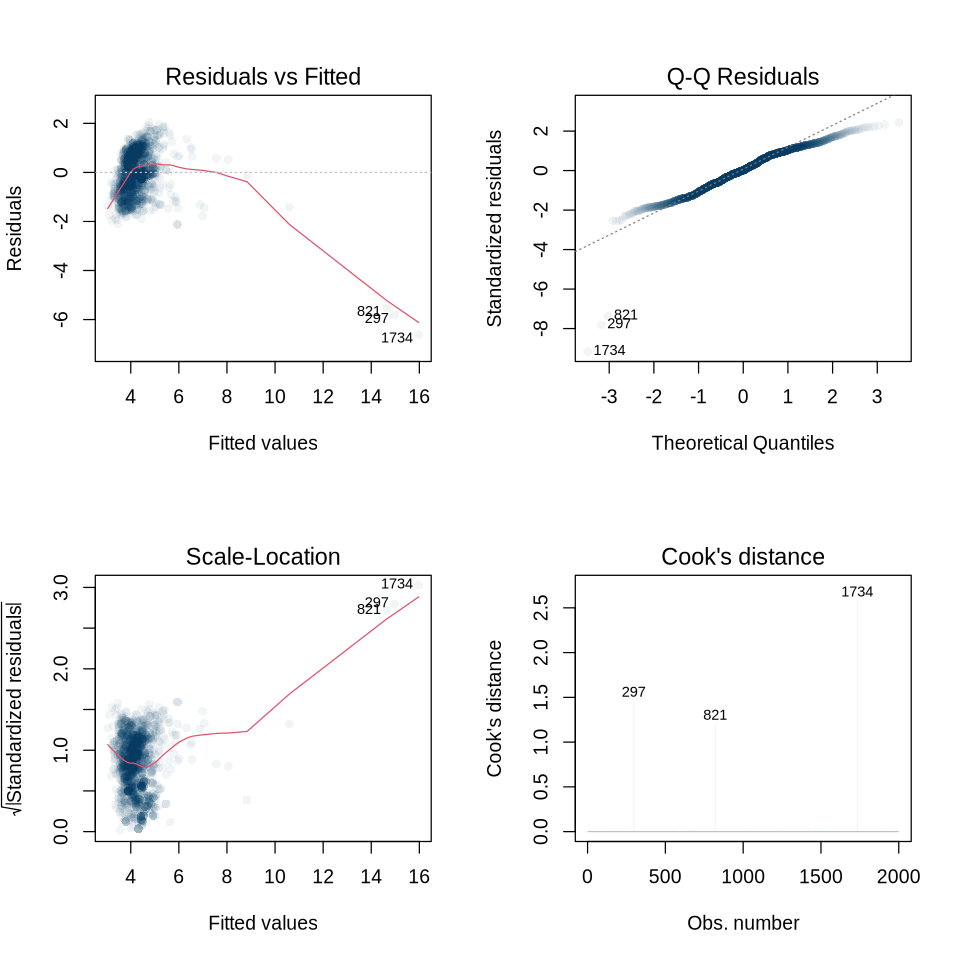


📌 DIAGNOSTIC GUIDE:
  Plot 1 (Residuals vs Fitted) : Should show no pattern → linearity holds
  Plot 2 (Q-Q Plot)            : Points on diagonal → normality of residuals
  Plot 3 (Scale-Location)      : Flat line → homoscedasticity
  Plot 4 (Cook's Distance)     : No points > 0.5 → no high-leverage outliers

In [0]:
par(mfrow = c(2, 2))
plot(mlr_model, which = 1:4, col = "#0d3b660D", pch = 16)
par(mfrow = c(1, 1))

cat("\n📌 DIAGNOSTIC GUIDE:\n")
cat("  Plot 1 (Residuals vs Fitted) : Should show no pattern → linearity holds\n")
cat("  Plot 2 (Q-Q Plot)            : Points on diagonal → normality of residuals\n")
cat("  Plot 3 (Scale-Location)      : Flat line → homoscedasticity\n")
cat("  Plot 4 (Cook's Distance)     : No points > 0.5 → no high-leverage outliers\n")


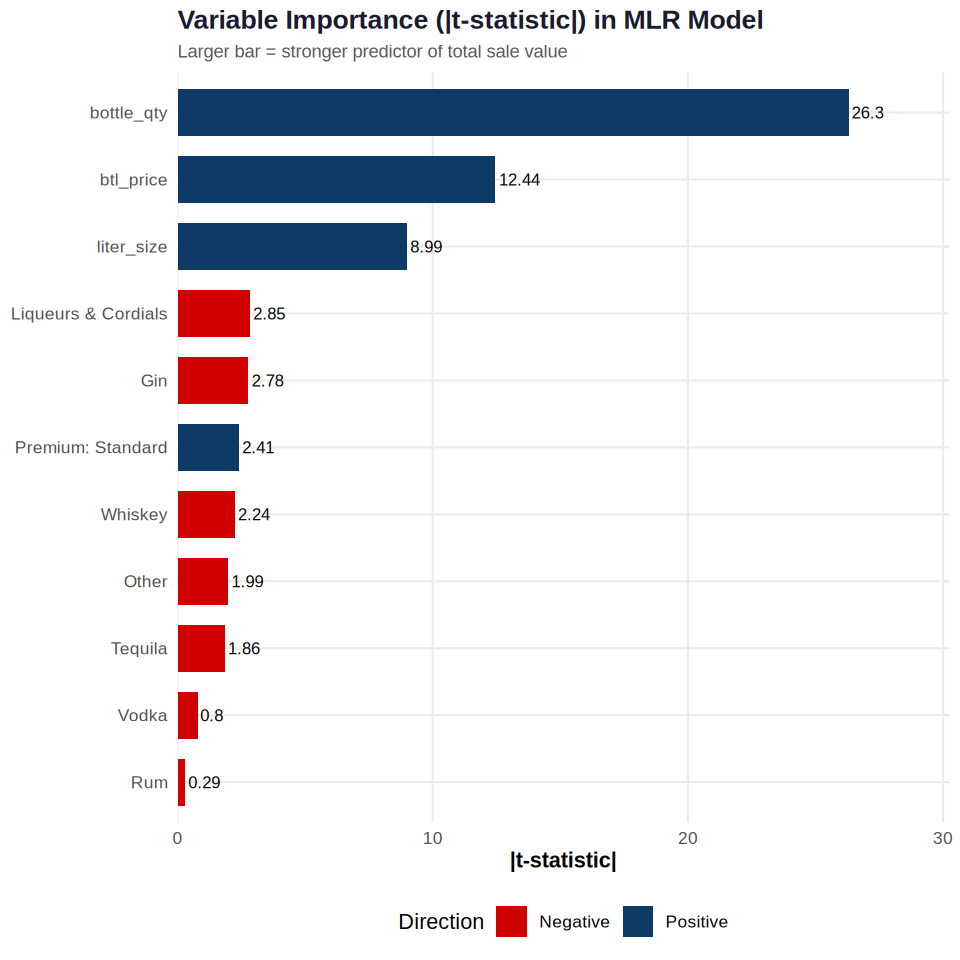

In [0]:
importance <- tidy_coef %>%
  filter(term != "(Intercept)") %>%
  mutate(
    abs_t    = abs(statistic),
    direction = ifelse(estimate > 0, "Positive", "Negative"),
    term      = str_replace_all(term, c("spirit_type" = "", "is_premium" = "Premium: "))
  ) %>%
  arrange(desc(abs_t))

p_importance <- ggplot(importance, aes(x = reorder(term, abs_t),
                                       y = abs_t, fill = direction)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = round(abs_t, 2)), hjust = -0.1, size = 3.5) +
  scale_fill_manual(values = c("Positive" = "#0d3b66", "Negative" = "#d00000")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  coord_flip() +
  labs(
    title    = "Variable Importance (|t-statistic|) in MLR Model",
    subtitle = "Larger bar = stronger predictor of total sale value",
    x        = NULL, y = "|t-statistic|", fill = "Direction"
  ) +
  theme_danmurphy

print(p_importance)

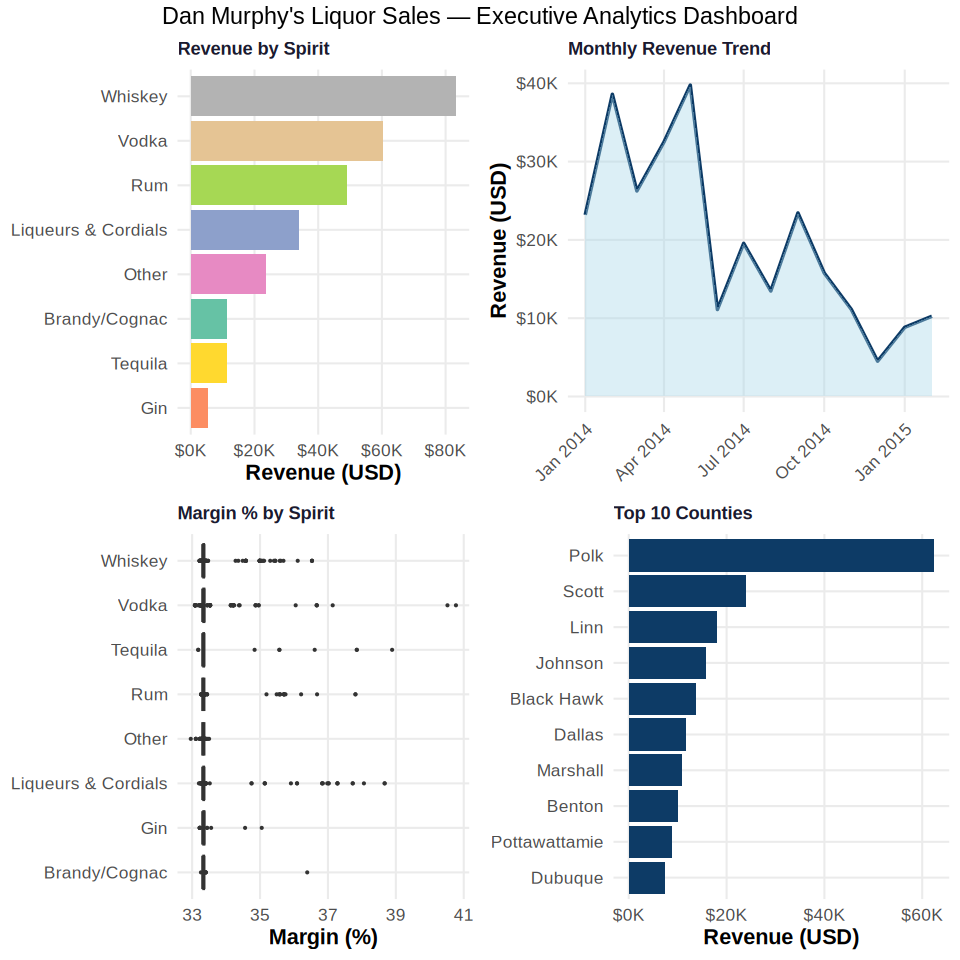


Attaching package: ‘gridExtra’

The following object is masked from ‘package:dplyr’:

    combine


In [0]:
library(gridExtra)

p1 <- ggplot(spirit_summary, aes(x = reorder(spirit_type, total_revenue), y = total_revenue, fill = spirit_type)) +
  geom_col(show.legend = FALSE) +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K")) +
  scale_fill_brewer(palette = "Set2") +
  coord_flip() +
  labs(title = "Revenue by Spirit", x = NULL, y = "Revenue (USD)") +
  theme_danmurphy + theme(plot.title = element_text(size = 11))

p2 <- ggplot(monthly_trend, aes(x = year_month, y = revenue)) +
  geom_line(colour = "#0d3b66", linewidth = 1) +
  geom_area(fill = "#a8d8ea", alpha = 0.4) +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K")) +
  labs(title = "Monthly Revenue Trend", x = NULL, y = "Revenue (USD)") +
  theme_danmurphy + theme(plot.title = element_text(size = 11),
                          axis.text.x = element_text(angle = 45, hjust = 1))

p3 <- ggplot(df, aes(x = spirit_type, y = margin_pct, fill = spirit_type)) +
  geom_boxplot(show.legend = FALSE, outlier.size = 0.5) +
  scale_fill_brewer(palette = "Pastel2") +
  coord_flip() +
  labs(title = "Margin % by Spirit", x = NULL, y = "Margin (%)") +
  theme_danmurphy + theme(plot.title = element_text(size = 11))

p4 <- ggplot(county_rev, aes(x = reorder(county, revenue), y = revenue)) +
  geom_col(fill = "#0d3b66") +
  scale_y_continuous(labels = dollar_format(scale = 1e-3, suffix = "K")) +
  coord_flip() +
  labs(title = "Top 10 Counties", x = NULL, y = "Revenue (USD)") +
  theme_danmurphy + theme(plot.title = element_text(size = 11))

grid.arrange(p1, p2, p3, p4, ncol = 2,
             top = "Dan Murphy's Liquor Sales \u2014 Executive Analytics Dashboard")